# SE4050 Deep Learning Assignment - Human Activity Recognition (HAR)
## Component 3: Bidirectional LSTM + Shared UCI HAR Data Loader

**Author:**  IT23265110 - Abeyrathne E.D.V.N
**Component:** Stacked Bidirectional LSTM for multi-channel sensor time-series
**Framework:** TensorFlow / Keras (trained from scratch)

This notebook uses the reusable modules in `src/` and does not re-implement them:
- `src/data/uci_har_loader.py` builds the shared, subject-split, train-standardized dataset
- `src/models/bilstm.py` holds the model builder
- `src/train_bilstm.py` holds the training pipeline (callbacks and run logging)

**Rule followed throughout:** the test split is used **once**, in Section 6, with the model chosen in Section 5. All tuning and model selection use the validation split only.

### 1. Setup: imports, seeds, repo path
In Colab (browser or the VS Code Colab extension), the cell clones the `dev` branch of the public repo into `/content/repo` and installs the requirements. No token is needed. Locally, the cell finds the repo root automatically.

In [15]:
import os
import sys
import json
from pathlib import Path

# True in Colab web and when VS Code is connected to a Colab server
IN_COLAB = "COLAB_RELEASE_TAG" in os.environ or Path("/content").exists()

if IN_COLAB:
    REPO_URL = "https://github.com/DharanaT567-del/Deep-Learning-Assignment-SE4050.git"
    BRANCH = "dev"
    if not Path("/content/repo").exists():
        os.system(f"git clone --branch {BRANCH} {REPO_URL} /content/repo")
    else:
        os.system("git -C /content/repo pull")
    os.chdir("/content/repo")
    os.system("pip install -q -r requirements.txt")
else:
    # Walk up from the notebook folder until the repo root is found
    root = Path.cwd()
    while not (root / "src" / "data_contract.py").exists() and root != root.parent:
        root = root.parent
    os.chdir(root)

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print("Project root:", PROJECT_ROOT)


Project root: /content/repo


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import keras
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, roc_auc_score

from src.data_contract import ACTIVITY_LABEL_MAPPING, load_har_npz, validate_har_dataset
from src.data.uci_har_loader import (
    DEFAULT_OUTPUT_PATH,
    build_processed_dataset,
    download_uci_har,
    print_dataset_summary,
    save_processed_dataset,
)
from src.models.bilstm import build_bilstm_model, load_bilstm_model, predict_bilstm
from src.train_bilstm import load_config, set_seed, train_bilstm_pipeline

SEED = 42
set_seed(SEED)
CLASS_NAMES = [ACTIVITY_LABEL_MAPPING[i] for i in range(6)]

print("TensorFlow:", tf.__version__, "| Keras:", keras.__version__)
print("GPU:", tf.config.list_physical_devices("GPU") or "none (CPU)")

TensorFlow: 2.20.0 | Keras: 3.13.2
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### 2. Load the data with the shared loader
If `data/uci_har_processed.npz` is missing, it is built from the raw dataset (downloaded first if needed). The printed subject lists are the audit trail: no subject appears in more than one split.

In [17]:
NPZ_PATH = DEFAULT_OUTPUT_PATH

if not NPZ_PATH.exists():
    dataset_dir = download_uci_har()
    save_processed_dataset(build_processed_dataset(dataset_dir, n_val_subjects=4, seed=SEED), NPZ_PATH)

data = load_har_npz(str(NPZ_PATH))            # already standardized with train statistics
validate_har_dataset(data, check_test=True)   # raises on shape, label or subject-leakage problems
print_dataset_summary(data)


[Summary] Array shapes:
  X_train        (5952, 128, 9)  float32
  y_train        (5952,)  int64
  subject_train  (5952,)  int64
  X_val          (1400, 128, 9)  float32
  y_val          (1400,)  int64
  subject_val    (1400,)  int64
  X_test         (2947, 128, 9)  float32
  y_test         (2947,)  int64
  subject_test   (2947,)  int64

[Summary] Subjects per split:
  train (17 subjects): [1, 5, 6, 7, 8, 11, 14, 15, 17, 19, 21, 25, 26, 27, 28, 29, 30]
  val   ( 4 subjects): [3, 16, 22, 23]
  test  ( 9 subjects): [2, 4, 9, 10, 12, 13, 18, 20, 24]
  overlap train/val  none
  overlap train/test none
  overlap val/test   none

[Summary] Class counts per split:
  class                    train     val    test
  0 WALKING                 1012     214     496
  1 WALKING_UPSTAIRS         870     203     471
  2 WALKING_DOWNSTAIRS       800     186     420
  3 SITTING                 1035     251     491
  4 STANDING                1104     270     532
  5 LAYING                  1131     27

In [18]:
X_train, y_train = data["X_train"], data["y_train"]
X_val, y_val = data["X_val"], data["y_val"]

# Per-channel means after standardization: ~0 for train, NOT exactly 0 for val (train statistics applied)
print("train channel means:", np.round(X_train.mean(axis=(0, 1)), 3))
print("val   channel means:", np.round(X_val.mean(axis=(0, 1)), 3))

train channel means: [ 0. -0.  0.  0.  0. -0.  0.  0.  0.]
val   channel means: [ 0.001  0.001  0.005  0.032 -0.007 -0.017  0.015 -0.068 -0.012]


### 3. Build the model
Baseline configuration from `configs/bilstm.json`: 2 stacked bidirectional LSTM layers with 64 units per direction, dropout 0.4, a Dense(64) head, and Adam with lr 5e-4 and `clipnorm=1.0`.

In [19]:
config = load_config("configs/bilstm.json")
print(json.dumps(config, indent=2))

m = config["model"]
model = build_bilstm_model(
    input_shape=(m["seq_len"], m["num_features"]),
    n_classes=m["num_classes"],
    lstm_units=m["lstm_units"],
    n_layers=m["n_layers"],
    dropout=m["dropout"],
    dense_units=m["dense_units"],
    learning_rate=config["training"]["learning_rate"],
    seed=SEED,
    pooling=m["pooling"],
)
model.summary()

{
  "model": {
    "seq_len": 128,
    "num_features": 9,
    "lstm_units": 64,
    "n_layers": 2,
    "dropout": 0.4,
    "dense_units": 64,
    "num_classes": 6
  },
  "training": {
    "learning_rate": 0.0005,
    "batch_size": 64,
    "epochs": 60,
    "seed": 42,
    "early_stopping_patience": 10,
    "reduce_lr_patience": 5,
    "reduce_lr_factor": 0.5,
    "min_lr": 1e-06
  },
  "data": {
    "npz_path": "data/uci_har_processed.npz",
    "normalize": false
  },
  "output": {
    "base_dir": "outputs/bilstm"
  }
}


Model: "har_bilstm_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sensor_window_input             │ (None, 128, 9)         │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_1 (Bidirectional)        │ (None, 128, 128)       │        37,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_dropout_1 (Dropout)      │ (None, 128, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_2 (Bidirectional)        │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_dropout_2 (Dropout)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_classification_head       │ (None, 64)             │         8,256 │
│ (Dense)                         │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activity_probabilities (Dense)  │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 145,350 (567.77 KB)

 Trainable params: 145,350 (567.77 KB)

 Non-trainable params: 0 (0.00 B)

### 4. Train with callbacks
`train_bilstm_pipeline` trains on train and monitors **val_loss** for EarlyStopping (patience 10, best weights restored), ModelCheckpoint and ReduceLROnPlateau. It writes all artifacts to `outputs/bilstm/run_<timestamp>/`.

In [20]:
baseline_model, baseline_meta, baseline_dir = train_bilstm_pipeline(config, data=data, verbose=2)

[Data Contract] Validated successfully.
  Train windows: 5952 (Subjects: [1, 5, 6, 7, 8, 11, 14, 15, 17, 19, 21, 25, 26, 27, 28, 29, 30])
  Val windows:   1400 (Subjects: [3, 16, 22, 23])
  Input window shape: (128, 9)
[Model Architecture] Built 'har_bilstm_classifier'
  Total parameters:     145,350
  Trainable parameters: 145,350
[Training] Starting training: epochs=60, batch_size=64, lr=0.0005...
Epoch 1/60

Epoch 1: val_loss improved from None to 0.48555, saving model to outputs/bilstm/run_20260926_162431/best_model.keras

Epoch 1: finished saving model to outputs/bilstm/run_20260926_162431/best_model.keras
93/93 - 6s - 64ms/step - accuracy: 0.6504 - loss: 0.9884 - val_accuracy: 0.8350 - val_loss: 0.4855 - learning_rate: 5.0000e-04
Epoch 2/60

Epoch 2: val_loss improved from 0.48555 to 0.33321, saving model to outputs/bilstm/run_20260926_162431/best_model.keras

Epoch 2: finished saving model to outputs/bilstm/run_20260926_162431/best_model.keras
93/93 - 2s - 25ms/step - accuracy: 

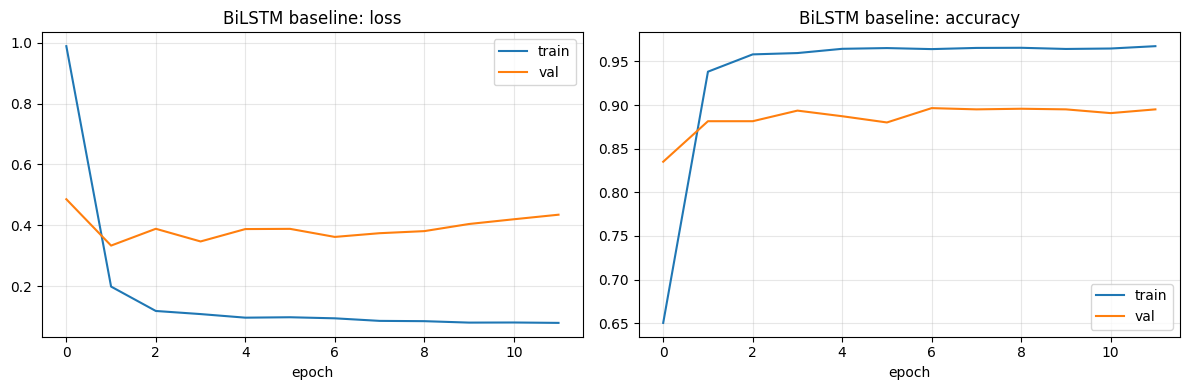

{'epochs_trained': 12, 'best_val_loss_epoch': 2, 'best_val_loss': 0.3332051932811737, 'val_accuracy_at_best_epoch': 0.881428599357605, 'duration_seconds': 32.36, 'seconds_per_epoch': 2.7, 'total_parameters': 145350}


In [21]:
def plot_history(run_dir, title):
    hist = json.load(open(Path(run_dir) / "history.json"))
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(hist["loss"], label="train")
    axes[0].plot(hist["val_loss"], label="val")
    axes[0].set_title(f"{title}: loss")
    axes[1].plot(hist["accuracy"], label="train")
    axes[1].plot(hist["val_accuracy"], label="val")
    axes[1].set_title(f"{title}: accuracy")
    for ax in axes:
        ax.set_xlabel("epoch")
        ax.legend()
        ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_history(baseline_dir, "BiLSTM baseline")
print({k: baseline_meta[k] for k in ["epochs_trained", "best_val_loss_epoch", "best_val_loss",
                                      "val_accuracy_at_best_epoch", "duration_seconds",
                                      "seconds_per_epoch", "total_parameters"]})

### 5. Hyperparameter tuning (validation split only)
Each variant changes **one** thing from the baseline, so any difference can be attributed to that change. The last three test the two improvements, separately and together:
- **Augmentation** targets the subject gap (validation loss rises after epoch 2). Training windows are randomly jittered, rescaled per channel and shifted in time, so the model sees more ways of performing each activity. Validation and test windows are never changed.
- **Attention pooling** targets the last-state bottleneck. Instead of summarising the window with the final BiLSTM state only, a learned softmax weighting over all 128 time steps is used (+129 parameters).

Every variant uses the same data, seed, epoch budget and callbacks. Variants are ranked by **best validation loss**, with validation accuracy at that epoch reported alongside. The test split is not used here.

| Variant | Change from baseline |
| :--- | :--- |
| baseline | 64 units, 2 layers, lr 5e-4, last-state pooling, no augmentation |
| units_32 | 32 units per direction |
| layers_1 | 1 bidirectional layer |
| lr_1e-3 | learning rate 1e-3 |
| aug | train-only augmentation: jitter (std 0.05), per-channel scaling (std 0.1), time shift (up to ±8 steps) |
| attention | attention pooling over all 128 time steps |
| aug_attention | augmentation + attention pooling |

In [22]:
import copy

VARIANTS = {
    "units_32": {"model": {"lstm_units": 32}},
    "layers_1": {"model": {"n_layers": 1}},
    "lr_1e-3": {"training": {"learning_rate": 0.001}},
    "aug": {"training": {"augment": True}},
    "attention": {"model": {"pooling": "attention"}},
    "aug_attention": {"model": {"pooling": "attention"}, "training": {"augment": True}},
}

tuning_runs = {"baseline": (baseline_meta, baseline_dir)}
for name, overrides in VARIANTS.items():
    cfg = copy.deepcopy(config)
    for section, values in overrides.items():
        cfg[section].update(values)
    cfg["output"]["base_dir"] = "outputs/bilstm/tuning"
    print(f"\n===== Variant: {name} {overrides} =====")
    _, meta, run_dir = train_bilstm_pipeline(cfg, data=data, verbose=0)
    tuning_runs[name] = (meta, run_dir)


===== Variant: units_32 {'model': {'lstm_units': 32}} =====
[Data Contract] Validated successfully.
  Train windows: 5952 (Subjects: [1, 5, 6, 7, 8, 11, 14, 15, 17, 19, 21, 25, 26, 27, 28, 29, 30])
  Val windows:   1400 (Subjects: [3, 16, 22, 23])
  Input window shape: (128, 9)
[Model Architecture] Built 'har_bilstm_classifier'
  Total parameters:     40,134
  Trainable parameters: 40,134
[Training] Starting training: epochs=60, batch_size=64, lr=0.0005...

[Run Completed] Duration: 31.37s | Best Val Loss: 0.42336854338645935 (Epoch 2)
  Artifacts saved to: outputs/bilstm/tuning/run_20260926_162505
  - Model:     outputs/bilstm/tuning/run_20260926_162505/best_model.keras
  - History:   outputs/bilstm/tuning/run_20260926_162505/history.json, outputs/bilstm/tuning/run_20260926_162505/history.csv
  - Metadata:  outputs/bilstm/tuning/run_20260926_162505/run_metadata.json

===== Variant: layers_1 {'model': {'n_layers': 1}} =====
[Data Contract] Validated successfully.
  Train windows: 5952

In [23]:
rows = []
for name, (meta, run_dir) in tuning_runs.items():
    cfg = json.load(open(Path(run_dir) / "config.json"))
    rows.append({
        "variant": name,
        "lstm_units": cfg["model"]["lstm_units"],
        "n_layers": cfg["model"]["n_layers"],
        "learning_rate": cfg["training"]["learning_rate"],
        "pooling": cfg["model"].get("pooling", "last"),
        "augment": cfg["training"].get("augment", False),
        "params": meta["total_parameters"],
        "best_val_loss": round(meta["best_val_loss"], 4),
        "val_acc_at_best": round(meta["val_accuracy_at_best_epoch"], 4),
        "best_epoch": meta["best_val_loss_epoch"],
        "sec_per_epoch": meta["seconds_per_epoch"],
        "run_dir": run_dir,
    })

tuning_df = pd.DataFrame(rows).sort_values("best_val_loss").reset_index(drop=True)
print(tuning_df.drop(columns="run_dir").to_string(index=False))

CHOSEN = tuning_df.iloc[0]
print(f"\nChosen variant (lowest validation loss): {CHOSEN['variant']}  ->  {CHOSEN['run_dir']}")

 variant  lstm_units  n_layers  learning_rate  params  best_val_loss  val_acc_at_best  best_epoch  sec_per_epoch
baseline          64         2         0.0005  145350         0.3332           0.8814           2           2.70
layers_1          64         1         0.0005   46534         0.3350           0.8886           5           1.60
 lr_1e-3          64         2         0.0010  145350         0.3442           0.8950           3           2.88
units_32          32         2         0.0005   40134         0.4234           0.8750           2           2.61

Chosen variant (lowest validation loss): baseline  ->  outputs/bilstm/run_20260926_162431


**Tuning results and choice.**

| Variant | Units | Layers | LR | Params | Best val loss | Val acc at best epoch | Best epoch | s/epoch (T4 GPU) |
| :--- | ---: | ---: | ---: | ---: | ---: | ---: | ---: | ---: |
| **baseline** | 64 | 2 | 5e-4 | 145,350 | **0.3332** | 0.8814 | 2 | 2.7 |
| layers_1 | 64 | 1 | 5e-4 | 46,534 | 0.3350 | 0.8886 | 5 | 1.6 |
| lr_1e-3 | 64 | 2 | 1e-3 | 145,350 | 0.3442 | **0.8950** | 3 | 2.9 |
| units_32 | 32 | 2 | 5e-4 | 40,134 | 0.4234 | 0.8750 | 2 | 2.6 |

**Chosen: `baseline`** (64 units, 2 layers, learning rate 5e-4). It had the lowest validation loss, which is the selection rule fixed before tuning. The margin is tiny. `layers_1` is only 0.002 behind with 68% fewer parameters, and `lr_1e-3` has the highest validation accuracy (89.5%) despite a higher loss. Only halving the units (`units_32`) is clearly worse (val loss 0.423). All four variants are within 2 points of validation accuracy (87.5–89.5%). That spread is close to the noise you would expect from 4 validation subjects. An earlier CPU run with the same seed ranked `lr_1e-3` first, because GPU (cuDNN) kernels are not fully deterministic and the TensorFlow versions differ. So the choice is a modest preference, not a clear win. Because the chosen model is the default configuration, `configs/bilstm.json` reproduces it directly.

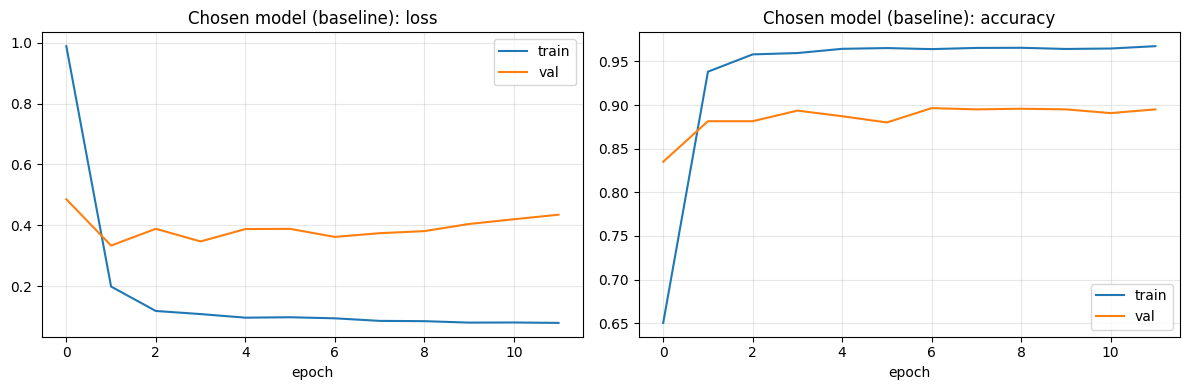

{'epochs_trained': 12, 'best_val_loss_epoch': 2, 'best_val_loss': 0.3332051932811737, 'val_accuracy_at_best_epoch': 0.881428599357605, 'duration_seconds': 32.36, 'seconds_per_epoch': 2.7}


In [24]:
# Learning curves of the chosen variant: train vs validation loss and accuracy per epoch
plot_history(CHOSEN["run_dir"], f"Chosen model ({CHOSEN['variant']})")
chosen_meta = tuning_runs[CHOSEN["variant"]][0]
print({k: chosen_meta[k] for k in ["epochs_trained", "best_val_loss_epoch", "best_val_loss",
                                    "val_accuracy_at_best_epoch", "duration_seconds", "seconds_per_epoch"]})

### 6. Final test evaluation (run once)
The chosen model's best checkpoint is evaluated on the held-out test split, which contains 9 subjects the model has never seen. This is the only cell that reads `X_test`.

Metrics: **accuracy** for overall correctness; **precision, recall and F1 per class**, plus their macro average, because a single accuracy figure hides which activities fail; **one-vs-rest ROC-AUC (macro)**, which scores the predicted probabilities and so shows how well each class is ranked independently of the argmax threshold; and the **confusion matrix**, which shows which activities are mistaken for which.

In [25]:
final_model = load_bilstm_model(str(Path(CHOSEN["run_dir"]) / "best_model.keras"))

X_test, y_test = data["X_test"], data["y_test"]
test_probs = predict_bilstm(final_model, X_test)
test_pred = np.argmax(test_probs, axis=-1)

test_metrics = {
    "variant": CHOSEN["variant"],
    "run_dir": CHOSEN["run_dir"],
    "test_accuracy": float(accuracy_score(y_test, test_pred)),
    "test_macro_f1": float(f1_score(y_test, test_pred, average="macro")),
    "test_weighted_f1": float(f1_score(y_test, test_pred, average="weighted")),
    # One-vs-rest ROC-AUC uses the predicted probabilities, not just the argmax class
    "test_roc_auc_ovr_macro": float(roc_auc_score(y_test, test_probs, multi_class="ovr", average="macro")),
    "num_test_samples": int(len(y_test)),
    "test_subjects": sorted(int(s) for s in np.unique(data["subject_test"])),
}
print(json.dumps({k: v for k, v in test_metrics.items() if k != "test_subjects"}, indent=2))
print()
print(classification_report(y_test, test_pred, target_names=CLASS_NAMES, digits=4))

{
  "variant": "baseline",
  "run_dir": "outputs/bilstm/run_20260926_162431",
  "test_accuracy": 0.8890397013912453,
  "test_macro_f1": 0.8881236051103176,
  "test_weighted_f1": 0.888788967175629,
  "test_roc_auc_ovr_macro": 0.9834229264728336,
  "num_test_samples": 2947
}

                    precision    recall  f1-score   support

           WALKING     0.9361    0.8569    0.8947       496
  WALKING_UPSTAIRS     0.9251    0.8917    0.9081       471
WALKING_DOWNSTAIRS     0.8166    0.9857    0.8932       420
           SITTING     0.8568    0.7556    0.8030       491
          STANDING     0.8104    0.8759    0.8419       532
            LAYING     1.0000    0.9758    0.9877       537

          accuracy                         0.8890      2947
         macro avg     0.8908    0.8903    0.8881      2947
      weighted avg     0.8931    0.8890    0.8888      2947



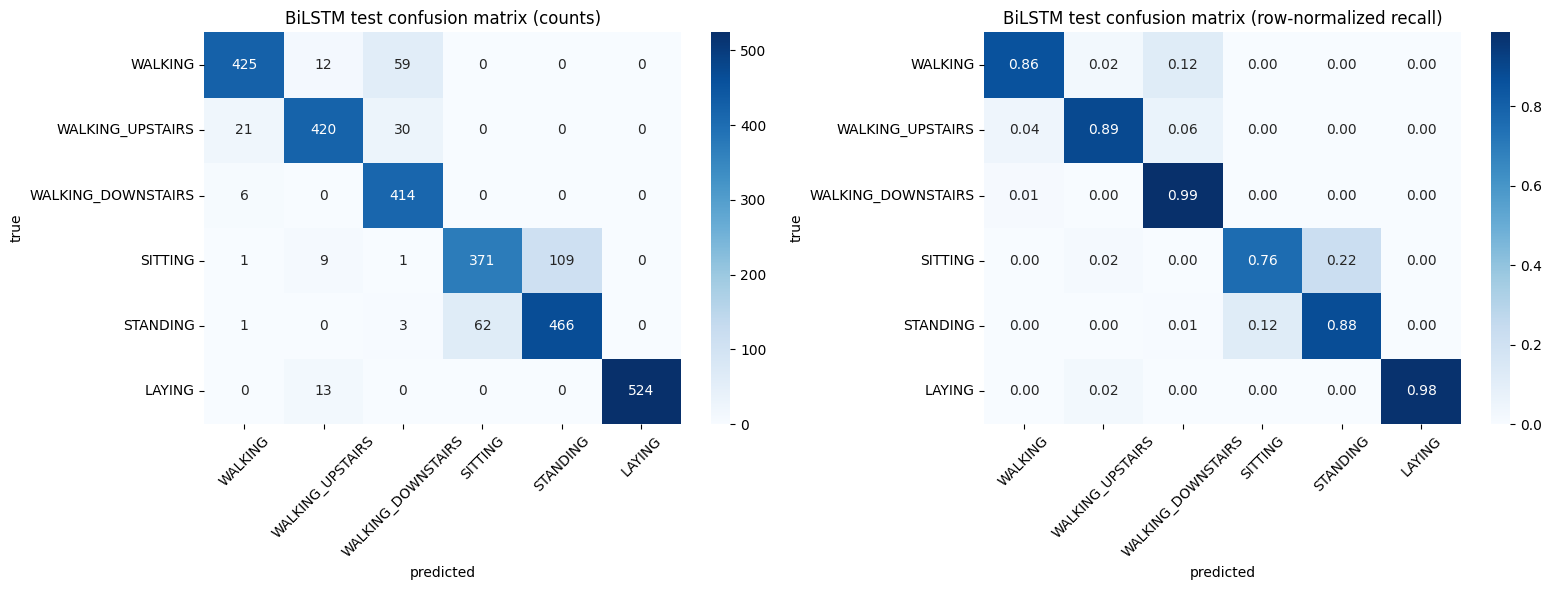

             SITTING -> STANDING             109
            STANDING -> SITTING              62
             WALKING -> WALKING_DOWNSTAIRS   59
    WALKING_UPSTAIRS -> WALKING_DOWNSTAIRS   30
    WALKING_UPSTAIRS -> WALKING              21


In [26]:
cm = confusion_matrix(y_test, test_pred)
cm_norm = cm / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title("BiLSTM test confusion matrix (counts)")
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
axes[1].set_title("BiLSTM test confusion matrix (row-normalized recall)")
for ax in axes:
    ax.set_xlabel("predicted")
    ax.set_ylabel("true")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

# Largest off-diagonal confusions
off_diag = [(CLASS_NAMES[i], CLASS_NAMES[j], int(cm[i, j])) for i in range(6) for j in range(6) if i != j and cm[i, j] > 0]
for true_c, pred_c, n in sorted(off_diag, key=lambda t: -t[2])[:5]:
    print(f"{true_c:>20} -> {pred_c:<20} {n}")

#### Attention weights
If the chosen model uses attention pooling, this plot shows which of the 128 time steps it weights most, averaged per true class on the test windows. It only visualises the already-chosen model; nothing here feeds back into model selection. A flat line at 1/128 would mean attention adds nothing over plain averaging.

In [ ]:
if any(layer.name == "temporal_attention_pool" for layer in final_model.layers):
    pool = final_model.get_layer("temporal_attention_pool")
    sequence_model = keras.Model(final_model.input, pool.input)
    sequences = sequence_model.predict(X_test, batch_size=256, verbose=0)
    attention = keras.ops.convert_to_numpy(pool.attention_weights(sequences))  # (N, 128)

    att_fig, ax = plt.subplots(figsize=(12, 4))
    for k, class_name in enumerate(CLASS_NAMES):
        ax.plot(attention[y_test == k].mean(axis=0), label=class_name)
    ax.axhline(1 / attention.shape[1], color="grey", linestyle="--", linewidth=1, label="uniform (1/128)")
    ax.set_title("Mean attention weight per time step, by true class (test split)")
    ax.set_xlabel("time step (50 Hz, 128 steps = 2.56 s)")
    ax.set_ylabel("attention weight")
    ax.legend(ncol=4, fontsize=8)
    plt.tight_layout()
    plt.show()
    att_fig.savefig(Path(CHOSEN["run_dir"]) / "attention_weights.png", dpi=150, bbox_inches="tight")
else:
    print(f"Chosen variant '{CHOSEN['variant']}' has no attention pooling layer; nothing to plot.")

### 7. Save the model and metrics
The metrics, tuning table and confusion matrix are saved next to the chosen model. Member 4's shared evaluation can then pick them up without re-running this notebook.

In [27]:
chosen_dir = Path(CHOSEN["run_dir"])
test_metrics["confusion_matrix"] = cm.tolist()
test_metrics["class_names"] = CLASS_NAMES

with open(chosen_dir / "test_metrics.json", "w", encoding="utf-8") as f:
    json.dump(test_metrics, f, indent=2)
tuning_df.to_csv(chosen_dir / "tuning_results.csv", index=False)
fig.savefig(chosen_dir / "confusion_matrix.png", dpi=150, bbox_inches="tight")

print("Saved to", chosen_dir)
for p in sorted(chosen_dir.iterdir()):
    print("  -", p.name)

Saved to outputs/bilstm/run_20260926_162431
  - best_model.keras
  - config.json
  - confusion_matrix.png
  - history.csv
  - history.json
  - run_metadata.json
  - test_metrics.json
  - tuning_results.csv


### 8. Observations

- **Convergence speed.** The BiLSTM converges very quickly. Validation accuracy passes 83% after one epoch, and the best validation loss comes at epoch 2–5 for every variant. Early stopping (patience 10) then ends each run after 12–15 epochs, which is about 24–37 s on a Colab T4 GPU at 1.6–2.9 s per epoch. The recurrence over 128 steps has to run sequentially, so each epoch costs more than a convolutional model of similar size would.
- **Training stability.** With gradient clipping (`clipnorm=1.0`) the loss never spiked or went NaN, even at lr 1e-3. ReduceLROnPlateau halved the learning rate twice in the baseline run (epochs 7 and 12) once validation loss stalled.
- **Overfitting evidence.** Training accuracy keeps climbing to about 96–97%, while validation accuracy plateaus at about 88–90% and validation loss drifts upward after its minimum (0.333 at epoch 2, 0.435 at epoch 12). That gap of about 7–8 points is a subject gap: the validation windows come from 4 people the model has never seen. Restoring the best weights from early stopping is therefore essential.
- **Test result.** The chosen model reaches **88.9% test accuracy, 0.888 macro F1 and 0.983 macro ROC-AUC (one-vs-rest)** on the 9 held-out test subjects. ROC-AUC ranks each class across all windows rather than scoring only the top prediction, so it stays high despite 327 errors out of 2,947. This is in line with its validation accuracy (88.1%), which suggests the subject-wise validation split was a faithful proxy for the test set.
- **Confused classes.** The largest error by far is **SITTING predicted as STANDING (109 of 491 sitting windows, 75.6% recall)**, plus 62 STANDING windows predicted as SITTING. A waist-mounted phone sees an almost identical gravity vector in both postures, and neither posture involves motion that the LSTM can use. The dynamic classes are confused mostly with each other (WALKING predicted as WALKING_DOWNSTAIRS: 59; WALKING_UPSTAIRS predicted as WALKING_DOWNSTAIRS: 30 and as WALKING: 21). As a result WALKING_DOWNSTAIRS has the highest recall of the dynamic classes (98.6%) but the lowest precision of all classes (81.7%): the model over-predicts it. LAYING is almost perfect (100% precision, 97.6% recall), because gravity lies on a different axis.